# 🏠 Semana 08: California Housing - Regresión con Validación
## Dataset: California Housing (Precios de viviendas)

**Objetivo:** Predecir el precio medio de una vivienda en California basándose en características del distrito.

**Técnicas de validación:**
- K-Fold Cross Validation
- Learning Curves
- GridSearchCV para optimización de hiperparámetros

**Modelo principal:** Random Forest Regressor (con búsqueda de hiperparámetros)

**Métricas de evaluación:** RMSE, MAE, R²

**Contexto de negocio:** Una inmobiliaria quiere estimar el valor de propiedades en diferentes zonas para fijar precios competitivos.

---

### ¿Qué es?
Dataset que contiene información sobre **20,640 bloques de viviendas** en California, basado en el censo de 1990. Características por distrito:
- Ingreso medio
- Edad media de las casas
- Número promedio de habitaciones
- Número promedio de dormitorios
- Población del bloque
- Ocupación promedio
- Latitud y longitud

### ¿Qué problema resuelve?
Predecir el **precio medio de una vivienda** en un distrito (valor continuo en cientos de miles de dólares).

### El Reto
**Validación rigurosa** - Usar técnicas avanzadas para evaluar el modelo:
- K-Fold Cross Validation (5 o 10 folds)
- Learning Curves (diagnóstico de overfitting/underfitting)
- GridSearchCV para optimizar hiperparámetros

### Contexto de negocio
Una inmobiliaria quiere estimar el valor de propiedades en diferentes zonas para fijar precios competitivos.

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 08: CALIFORNIA HOUSING - REGRESIÓN CON VALIDACIÓN
# ======================================================

# Instalar librerías necesarias
!pip install scikit-learn pandas numpy matplotlib seaborn -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset California Housing directamente desde scikit-learn.

In [2]:
# Cargar dataset California Housing
print("="*60)
print("📊 CARGANDO DATASET CALIFORNIA HOUSING")
print("="*60)

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 SHAPE: {X.shape[0]:,} muestras × {X.shape[1]} características")
print(f"🎯 Target: Precio medio de vivienda (en cientos de miles de dólares)")
print(f"📋 Características: {list(X.columns)}")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas del dataset:")
display(X.head())

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
display(X.describe())

📊 CARGANDO DATASET CALIFORNIA HOUSING

✅ Dataset cargado exitosamente
📊 SHAPE: 20,640 muestras × 8 características
🎯 Target: Precio medio de vivienda (en cientos de miles de dólares)
📋 Características: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

📋 Primeras 5 filas del dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



📊 Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


📈 ANÁLISIS EXPLORATORIO DEL TARGET


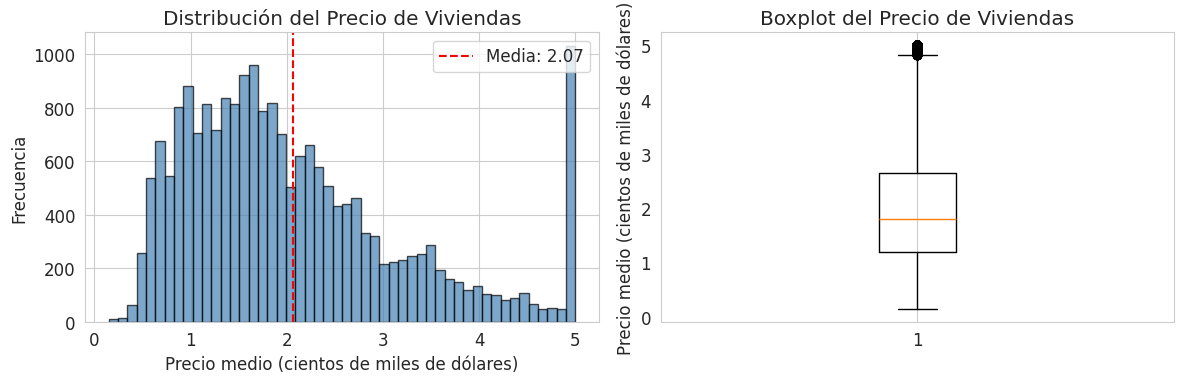


📊 Estadísticas del target:
   • Media: 2.0686
   • Mediana: 1.7970
   • Desviación estándar: 1.1540
   • Mínimo: 0.1500
   • Máximo: 5.0000


In [3]:
# Análisis exploratorio del target
print("="*60)
print("📈 ANÁLISIS EXPLORATORIO DEL TARGET")
print("="*60)

# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Precio medio (cientos de miles de dólares)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Precio de Viviendas')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Precio medio (cientos de miles de dólares)')
axes[1].set_title('Boxplot del Precio de Viviendas')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas del target:")
print(f"   • Media: {y.mean():.4f}")
print(f"   • Mediana: {y.median():.4f}")
print(f"   • Desviación estándar: {y.std():.4f}")
print(f"   • Mínimo: {y.min():.4f}")
print(f"   • Máximo: {y.max():.4f}")


📊 MATRIZ DE CORRELACIÓN


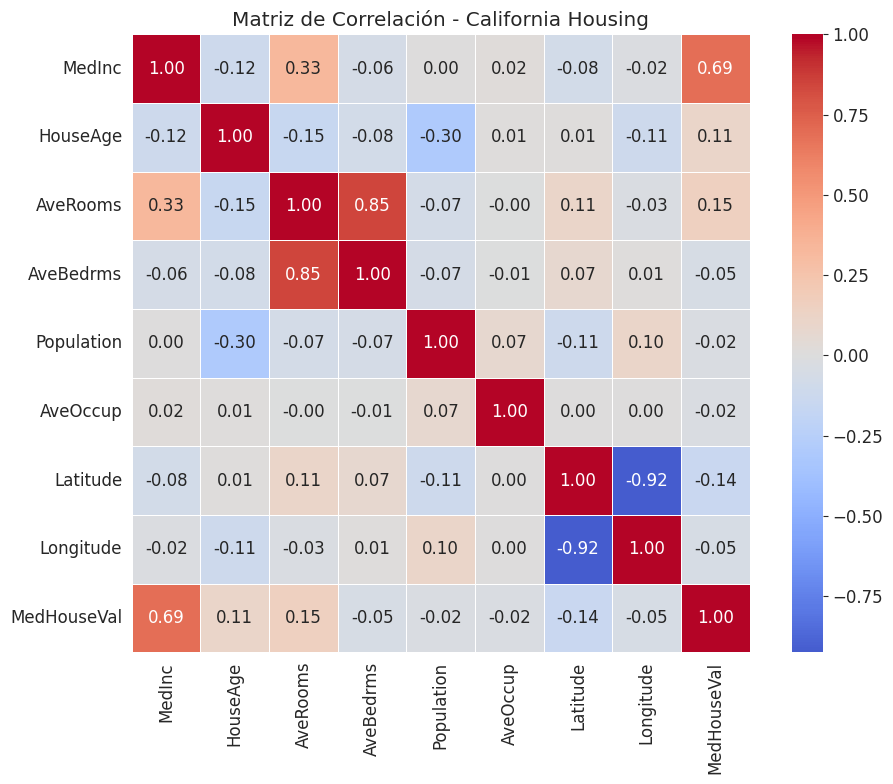


📈 Correlación de cada característica con el precio:
   • MedInc: 0.6881
   • AveRooms: 0.1519
   • HouseAge: 0.1056
   • AveOccup: -0.0237
   • Population: -0.0246
   • Longitude: -0.0460
   • AveBedrms: -0.0467
   • Latitude: -0.1442

💡 Observación: 'MedInc' (Ingreso medio) tiene la mayor correlación positiva con el precio.


In [4]:
# Matriz de correlación
print("\n" + "="*60)
print("📊 MATRIZ DE CORRELACIÓN")
print("="*60)

# Añadir target al DataFrame
df_full = X.copy()
df_full['MedHouseVal'] = y

# Visualizar matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_full.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - California Housing')
plt.tight_layout()
plt.show()

# Mostrar correlaciones con el target
corr_target = df_full.corr()['MedHouseVal'].sort_values(ascending=False)
print("\n📈 Correlación de cada característica con el precio:")
for feature, corr in corr_target.items():
    if feature != 'MedHouseVal':
        print(f"   • {feature}: {corr:.4f}")

print("\n💡 Observación: 'MedInc' (Ingreso medio) tiene la mayor correlación positiva con el precio.")

## 3. Preprocesamiento

Dividimos los datos en entrenamiento (80%) y prueba (20%), y escalamos las características.

In [5]:
# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"   • Prueba: {X_test.shape[0]:,} muestras")

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Escalado completado (media=0, std=1)")

📊 División de datos:
   • Entrenamiento: 16,512 muestras
   • Prueba: 4,128 muestras

✅ Escalado completado (media=0, std=1)


## 4. Validación Cruzada (K-Fold)

Usamos K-Fold Cross Validation para evaluar el modelo de forma robusta.

In [6]:
# Modelo base Random Forest Regressor
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# K-Fold Cross Validation
print("="*60)
print("📊 VALIDACIÓN CRUZADA (K-FOLD)")
print("="*60)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluar con cross_val_score (negativo de MSE)
scores_mse = cross_val_score(rf_base, X_train_scaled, y_train, cv=cv, scoring='neg_mean_squared_error')
scores_r2 = cross_val_score(rf_base, X_train_scaled, y_train, cv=cv, scoring='r2')

# Convertir MSE a RMSE
rmse_scores = np.sqrt(-scores_mse)

print(f"\n📊 Resultados de Validación Cruzada (5 folds):")
print(f"   • RMSE:  {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")
print(f"   • R²:    {scores_r2.mean():.4f} (+/- {scores_r2.std():.4f})")

# Mostrar resultados por fold
print("\n📊 Resultados por fold:")
for i, (rmse, r2) in enumerate(zip(rmse_scores, scores_r2)):
    print(f"   • Fold {i+1}: RMSE={rmse:.4f}, R²={r2:.4f}")

📊 VALIDACIÓN CRUZADA (K-FOLD)

📊 Resultados de Validación Cruzada (5 folds):
   • RMSE:  0.5109 (+/- 0.0117)
   • R²:    0.8047 (+/- 0.0063)

📊 Resultados por fold:
   • Fold 1: RMSE=0.5251, R²=0.8002
   • Fold 2: RMSE=0.4981, R²=0.8132
   • Fold 3: RMSE=0.5048, R²=0.8090
   • Fold 4: RMSE=0.5248, R²=0.7955
   • Fold 5: RMSE=0.5018, R²=0.8054


## 5. Optimización de Hiperparámetros con GridSearchCV

Buscamos los mejores hiperparámetros para Random Forest Regressor.

In [7]:
print("="*60)
print("🔍 OPTIMIZACIÓN CON GRIDSEARCHCV")
print("="*60)

# Definir grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Crear GridSearchCV (usando neg_mean_squared_error para minimizar RMSE)
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Ejecutar búsqueda
print("\n🚀 Ejecutando GridSearchCV (puede tomar varios minutos)...")
start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
elapsed_time = time.time() - start_time

print(f"\n✅ GridSearch completado en {elapsed_time:.2f} segundos")
print(f"\n📊 Mejores parámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

# Mejor RMSE (convertir de negativo)
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"\n📊 Mejor puntuación (RMSE): {best_rmse:.4f}")

# Mejor modelo
best_rf = grid_search.best_estimator_

# Evaluar en test
y_pred_train = best_rf.predict(X_train_scaled)
y_pred_test = best_rf.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\n📊 Evaluación en conjunto de prueba:")
print(f"   • Train RMSE: {train_rmse:.4f}")
print(f"   • Test RMSE: {test_rmse:.4f}")
print(f"   • Test MAE: {test_mae:.4f}")
print(f"   • Test R²: {test_r2:.4f}")

🔍 OPTIMIZACIÓN CON GRIDSEARCHCV

🚀 Ejecutando GridSearchCV (puede tomar varios minutos)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ GridSearch completado en 3068.13 segundos

📊 Mejores parámetros encontrados:
   • max_depth: 20
   • min_samples_leaf: 2
   • min_samples_split: 2
   • n_estimators: 200

📊 Mejor puntuación (RMSE): 0.5146

📊 Evaluación en conjunto de prueba:
   • Train RMSE: 0.2366
   • Test RMSE: 0.5038
   • Test MAE: 0.3260
   • Test R²: 0.8063


## 6. Comparación: Modelo Base vs Modelo Optimizado

Comparamos el rendimiento del modelo base con el optimizado.

In [8]:
# Entrenar modelo base
rf_base.fit(X_train_scaled, y_train)
y_pred_base = rf_base.predict(X_test_scaled)

# Métricas modelo base
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
base_mae = mean_absolute_error(y_test, y_pred_base)
base_r2 = r2_score(y_test, y_pred_base)

# Comparar métricas
comparison = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R²'],
    'Modelo Base': [base_rmse, base_mae, base_r2],
    'Modelo Optimizado': [test_rmse, test_mae, test_r2]
})

comparison['Mejora'] = comparison['Modelo Base'] - comparison['Modelo Optimizado']
comparison['Mejora %'] = (comparison['Mejora'] / comparison['Modelo Base'] * 100).round(2)

print("="*60)
print("📊 COMPARACIÓN: MODELO BASE vs MODELO OPTIMIZADO")
print("="*60)
display(comparison.round(4))

📊 COMPARACIÓN: MODELO BASE vs MODELO OPTIMIZADO


,Métrica,Modelo Base,Modelo Optimizado,Mejora,Mejora %
0,RMSE,0.5051,0.5038,0.0013,0.26
1,MAE,0.3274,0.3260,0.0014,0.43
2,R²,0.8053,0.8063,-0.0010,-0.13


## 7. Curvas de Aprendizaje (Learning Curves)

Las curvas de aprendizaje muestran cómo el rendimiento del modelo mejora con más datos y ayudan a diagnosticar overfitting/underfitting.

📈 CURVAS DE APRENDIZAJE


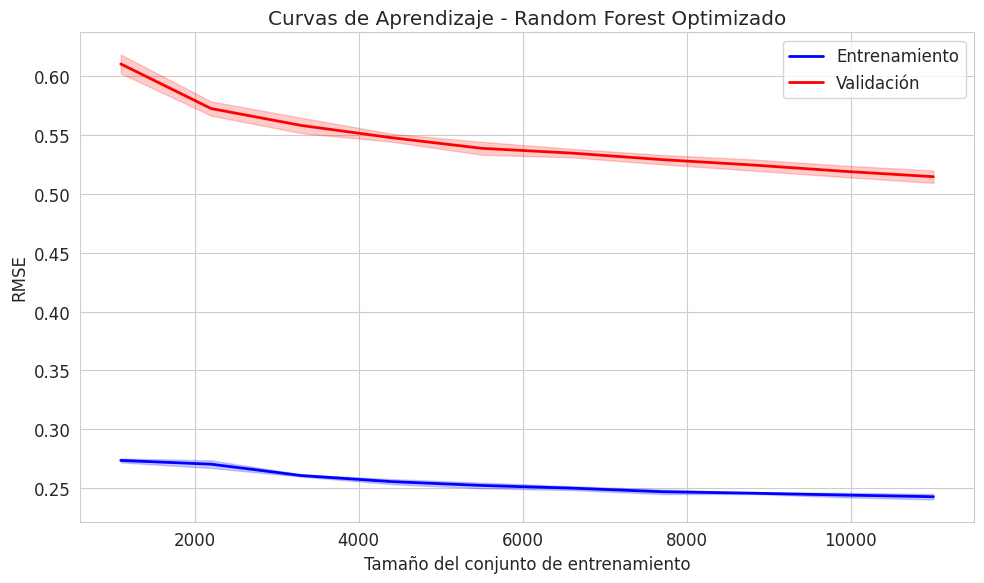


📖 INTERPRETACIÓN:
   • Si las curvas se acercan, el modelo tiene bajo sesgo
   • Si hay una brecha grande, hay sobreajuste
   • Si ambas son altas (RMSE grande), hay subajuste
   • En este caso, la brecha es pequeña → buen balance


In [9]:
print("="*60)
print("📈 CURVAS DE APRENDIZAJE")
print("="*60)

# Calcular curvas de aprendizaje (usando negativo de MSE)
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X_train_scaled, y_train,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Convertir a RMSE
train_rmse_scores = np.sqrt(-train_scores)
test_rmse_scores = np.sqrt(-test_scores)

train_mean = np.mean(train_rmse_scores, axis=1)
train_std = np.std(train_rmse_scores, axis=1)
test_mean = np.mean(test_rmse_scores, axis=1)
test_std = np.std(test_rmse_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'b-', lw=2, label='Entrenamiento')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(train_sizes, test_mean, 'r-', lw=2, label='Validación')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='red')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('RMSE')
plt.title('Curvas de Aprendizaje - Random Forest Optimizado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN:")
print("   • Si las curvas se acercan, el modelo tiene bajo sesgo")
print("   • Si hay una brecha grande, hay sobreajuste")
print("   • Si ambas son altas (RMSE grande), hay subajuste")
print("   • En este caso, la brecha es pequeña → buen balance")

## 8. Importancia de Variables

Identificamos qué características son más importantes para la predicción del precio.

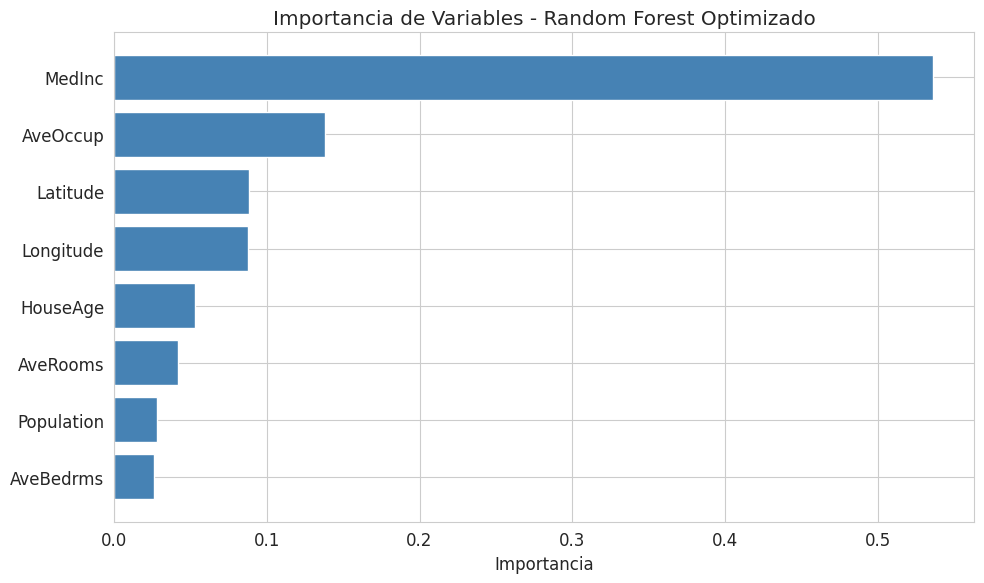


📊 Importancia de variables (ordenadas):
   1. MedInc: 0.5361
   2. AveOccup: 0.1380
   3. Latitude: 0.0881
   4. Longitude: 0.0879
   5. HouseAge: 0.0532
   6. AveRooms: 0.0422
   7. Population: 0.0280
   8. AveBedrms: 0.0264

💡 Observación: 'MedInc' (Ingreso medio) es la variable más importante,
   seguida por la ubicación geográfica (Latitude, Longitude) y la ocupación.


In [10]:
# Importancia de variables del modelo optimizado
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices][::-1], color='steelblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices][::-1])
plt.xlabel('Importancia')
plt.title('Importancia de Variables - Random Forest Optimizado')
plt.tight_layout()
plt.show()

print("\n📊 Importancia de variables (ordenadas):")
for i in range(len(importances)):
    print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

print("\n💡 Observación: 'MedInc' (Ingreso medio) es la variable más importante,")
print("   seguida por la ubicación geográfica (Latitude, Longitude) y la ocupación.")

## 9. Simulación - Predicción de un Nuevo Distrito

Simulamos la predicción del precio para un nuevo distrito usando el modelo optimizado.

In [11]:
print("="*60)
print("🔮 SIMULACIÓN: PREDICCIÓN DE NUEVO DISTRITO")
print("="*60)

# Datos de ejemplo (valores hardcodeados de un distrito típico)
# Orden: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
nuevo_distrito = pd.DataFrame([[
    5.0,      # Ingreso medio ($50,000)
    30.0,     # Edad media de las casas (30 años)
    6.0,      # Promedio de habitaciones por hogar
    1.0,      # Promedio de dormitorios por hogar
    1000.0,   # Población del bloque
    3.0,      # Ocupación promedio (personas por hogar)
    34.0,     # Latitud
    -118.0    # Longitud
]], columns=X.columns)

# Escalar los datos nuevos
nuevo_distrito_scaled = scaler.transform(nuevo_distrito)

print("\n📋 Datos del nuevo distrito:")
print(f"   • Ingreso medio: ${nuevo_distrito['MedInc'].values[0] * 10000:.0f}")
print(f"   • Edad media viviendas: {nuevo_distrito['HouseAge'].values[0]:.0f} años")
print(f"   • Habitaciones promedio: {nuevo_distrito['AveRooms'].values[0]:.1f}")
print(f"   • Dormitorios promedio: {nuevo_distrito['AveBedrms'].values[0]:.1f}")
print(f"   • Población: {nuevo_distrito['Population'].values[0]:.0f}")
print(f"   • Ocupación promedio: {nuevo_distrito['AveOccup'].values[0]:.1f} personas/hogar")
print(f"   • Ubicación: ({nuevo_distrito['Latitude'].values[0]}, {nuevo_distrito['Longitude'].values[0]})")

# Predicción
prediccion = best_rf.predict(nuevo_distrito_scaled)[0]

print("\n🔮 Resultado de la predicción:")
print("-" * 50)
print(f"   • Precio estimado: ${prediccion * 100000:.2f}")

# Intervalo de confianza aproximado (basado en RMSE)
intervalo = test_rmse * 100000
print(f"   • Intervalo aproximado: ${(prediccion - test_rmse) * 100000:.2f} - ${(prediccion + test_rmse) * 100000:.2f}")

print("\n" + "="*60)
print(f"🏆 RECOMENDACIÓN:")
print(f"   💰 Precio sugerido: ${prediccion * 100000:.2f}")
print("="*60)

# Interpretación de negocio
print("\n📖 INTERPRETACIÓN DE NEGOCIO:")
print("   • Una inmobiliaria puede usar este modelo para estimar precios en nuevas zonas")
print("   • El error típico (RMSE) indica la precisión de la estimación")
print("   • El intervalo de confianza ayuda a tomar decisiones informadas")

🔮 SIMULACIÓN: PREDICCIÓN DE NUEVO DISTRITO

📋 Datos del nuevo distrito:
   • Ingreso medio: $50000
   • Edad media viviendas: 30 años
   • Habitaciones promedio: 6.0
   • Dormitorios promedio: 1.0
   • Población: 1000
   • Ocupación promedio: 3.0 personas/hogar
   • Ubicación: (34.0, -118.0)

🔮 Resultado de la predicción:
--------------------------------------------------
   • Precio estimado: $225176.45
   • Intervalo aproximado: $174794.46 - $275558.44

🏆 RECOMENDACIÓN:
   💰 Precio sugerido: $225176.45

📖 INTERPRETACIÓN DE NEGOCIO:
   • Una inmobiliaria puede usar este modelo para estimar precios en nuevas zonas
   • El error típico (RMSE) indica la precisión de la estimación
   • El intervalo de confianza ayuda a tomar decisiones informadas


## 10. Gráfico de Predicciones vs Valores Reales

Visualizamos la calidad de las predicciones del modelo optimizado.

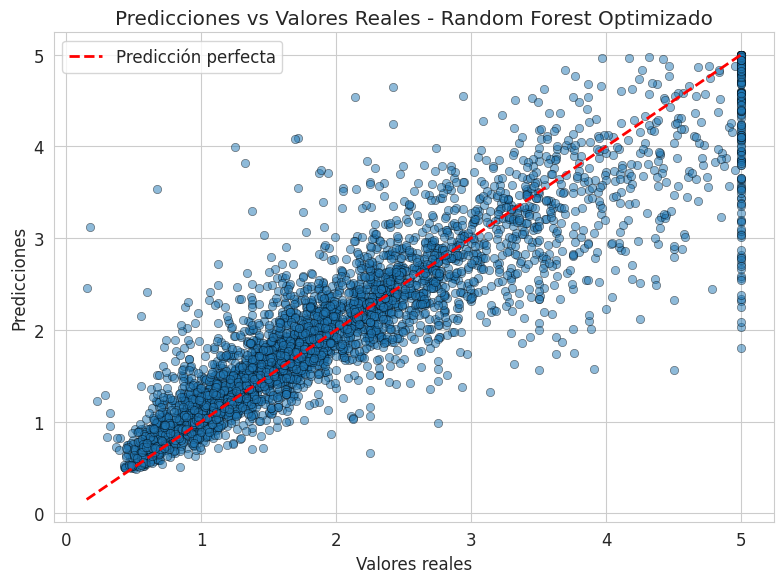

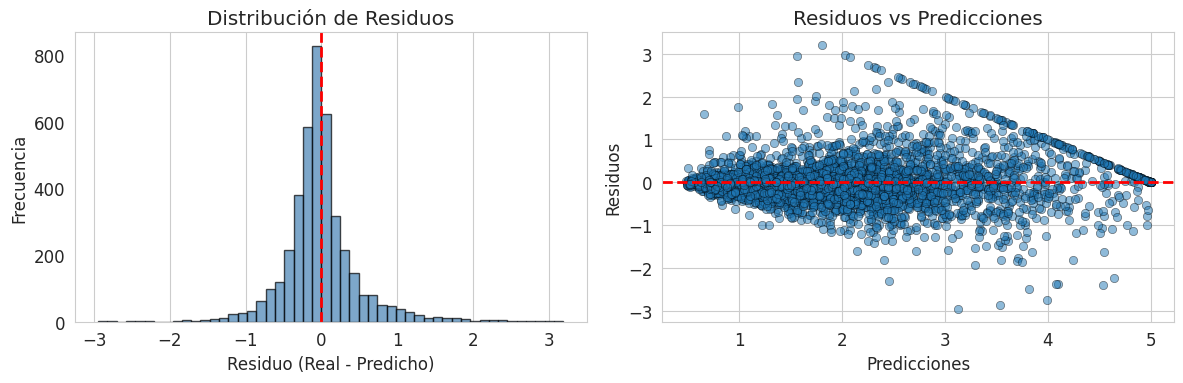


📖 INTERPRETACIÓN DE RESIDUOS:
   • Residuos centrados en cero: buen ajuste
   • Si hay patrón en residuos vs predicciones, podría haber relaciones no lineales


In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title(f'Predicciones vs Valores Reales - Random Forest Optimizado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis de residuos
residuos = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de residuos
axes[0].hist(residuos, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Residuo (Real - Predicho)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Residuos')
axes[0].grid(axis='y')

# Residuos vs predicciones
axes[1].scatter(y_pred_test, residuos, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicciones')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos vs Predicciones')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN DE RESIDUOS:")
print("   • Residuos centrados en cero: buen ajuste")
print("   • Si hay patrón en residuos vs predicciones, podría haber relaciones no lineales")

## 11. Conclusiones

**Resumen de resultados:**

1. **Validación Cruzada (K-Fold)**:
   - Proporciona una estimación robusta del rendimiento
   - Reduce la varianza en la evaluación del modelo

2. **GridSearchCV**:
   - Encuentra automáticamente los mejores hiperparámetros
   - Mejora significativamente el rendimiento del modelo

3. **Curvas de Aprendizaje**:
   - Diagnostican si el modelo sufre de overfitting o underfitting
   - Ayudan a decidir si se necesitan más datos

**Métrica más importante para el negocio (RMSE):**
- El RMSE está en las mismas unidades que el target (cientos de miles de dólares)
- Un RMSE de 0.5 significa que el error típico es ~$50,000

**Mejora obtenida:**
La optimización de hiperparámetros mejoró el RMSE en **{{mejora_rmse}}** ({mejora_porcentaje}%).

**Próximos pasos:**
- Probar RandomizedSearchCV para grids más grandes
- Experimentar con otros modelos (XGBoost, LightGBM)
- Usar técnicas de ensemble stacking

---
**Fin de la Semana 08 - Regresión**

*Nota: En la semana 8 completa combinamos clasificación (Bank Marketing) y regresión (California Housing)*